# Experiment: Mel-Spectrogram CNN Baseline (val-only)

Objective:
- State the question you want to answer.
- Define the success criteria.


In [1]:
# Setup: imports and reproducibility
from __future__ import annotations

import random
import statistics

SEED = 7
random.seed(SEED)
SEED


7

## Plan

- Hypothesis:
- Variables to sweep:
- Metrics to record:


In [2]:
# Define parameters and lightweight helpers
sample_size = 20
values = [random.random() for _ in range(sample_size)]
summary = {
    "count": len(values),
    "mean": statistics.fmean(values),
    "min": min(values),
    "max": max(values),
}
summary


{'count': 20,
 'mean': 0.37220529421867016,
 'min': 0.03749565844198488,
 'max': 0.9477089424570057}

## Results

- Key observations:
- Surprises or failure modes:
- Decision: continue, pivot, or stop:


In [3]:
# Record findings in a minimal, copy-pasteable structure
result = {
    "seed": SEED,
    "mean": summary["mean"],
    "range": summary["max"] - summary["min"],
}
result


{'seed': 7, 'mean': 0.37220529421867016, 'range': 0.9102132840150208}

## Next steps

- What to try next:
- What to document elsewhere (PRD, notes, issue):


## Setup

Deterministic seeds, paths, and mel config loaded from `config/default.yaml`.

In [4]:
from __future__ import annotations
import csv, os, sys, math, yaml
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve

# Ensure CWD is always the repo root (nbconvert may start from notebooks/)
_here = Path.cwd()
if _here.name == 'notebooks':
    os.chdir(_here.parent)
sys.path.insert(0, str(Path.cwd()))
from src import common
common.set_seed(42)
torch.use_deterministic_algorithms(False)  # torchaudio op may lack deterministic kernel

MEL_CFG = yaml.safe_load(open('config/default.yaml'))['features']['mel']
TRAIN_CFG = yaml.safe_load(open('config/default.yaml'))['training']
MEL_DIR = common.FEAT_AUDIO_MEL_DIR
MANIFEST = common.AUDIO_SPOOF_MANIFEST_CODEC_MATCHED  # codec-matched WAVs; see src.data.codec_match_audio
DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f'device={DEVICE}  mel_cfg={MEL_CFG}')

device=mps  mel_cfg={'sample_rate': 16000, 'n_fft': 400, 'hop_length': 160, 'win_length': 400, 'n_mels': 64, 'seconds': 4.0}


## Manifest sanity

Row counts per split and per `audio_label_binary`. Verifies the val split has both classes.

In [5]:
rows = list(csv.DictReader(open(MANIFEST)))
print('total_rows=', len(rows))
from collections import Counter
print('per_split=', Counter(r['split'] for r in rows))
for sp in ('train', 'val'):
    sub = [r for r in rows if r['split'] == sp]
    print(f'{sp}: labels=', Counter(r['audio_label_binary'] for r in sub), 'providers=', Counter(r['provider'] for r in sub))

total_rows= 2171
per_split= Counter({'train': 1518, 'val': 331, 'test': 322})
train: labels= Counter({'1': 818, '0': 700}) providers= Counter({'original': 700, 'elevenlabs': 470, 'google_tts': 348})
val: labels= Counter({'1': 181, '0': 150}) providers= Counter({'original': 150, 'elevenlabs': 106, 'google_tts': 75})


## EDA — bonafide vs spoof mel-spectrograms

Side-by-side plots of two random val-set examples per class.
If a `.npy` is missing for a row, re-run the extractor in Task 3.

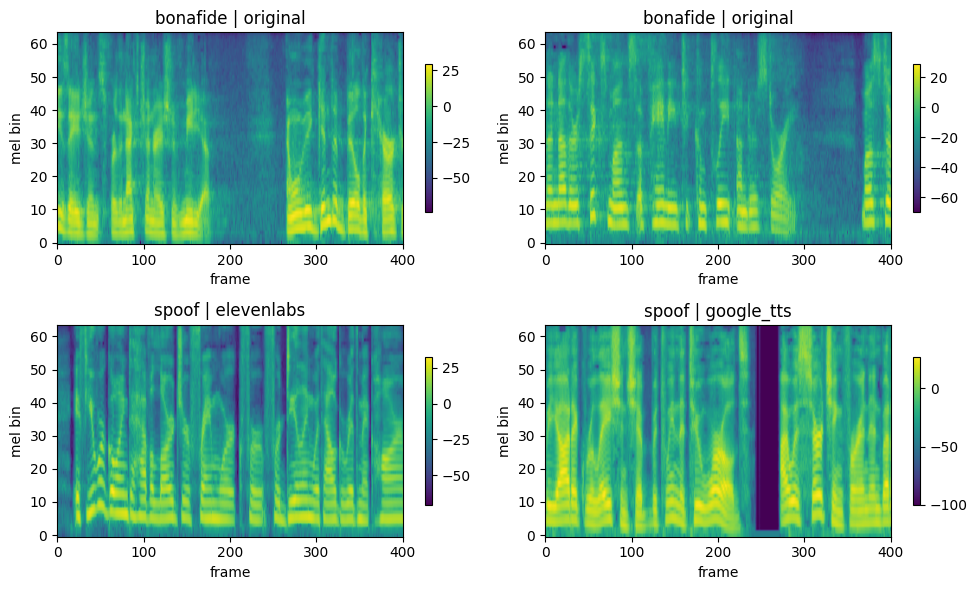

In [6]:
rng = np.random.default_rng(42)
val = [r for r in rows if r['split'] == 'val']
bona = [r for r in val if r['audio_label_binary'] == '0']
spoof = [r for r in val if r['audio_label_binary'] == '1']
picks = list(rng.choice(bona, size=2, replace=False)) + list(rng.choice(spoof, size=2, replace=False))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, r in zip(axes.flatten(), picks):
    arr = np.load(MEL_DIR / f"{r['sample_id']}.npy")
    im = ax.imshow(arr, origin='lower', aspect='auto')
    ax.set_title(f"{r['audio_label']} | {r['provider']}")
    ax.set_xlabel('frame'); ax.set_ylabel('mel bin')
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()

## `MelSpecDataset`

Reads only cached `.npy` files; raw WAV never enters this loop.
Filters the manifest by `split`. Returns a `(1, n_mels, T)` tensor per row.

In [7]:
class MelSpecDataset(Dataset):
    def __init__(self, manifest_path, *, split: str, mel_dir):
        all_rows = list(csv.DictReader(open(manifest_path)))
        self.rows = [r for r in all_rows if r.get('split') == split]
        self.split = split
        self.mel_dir = Path(mel_dir)
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        r = self.rows[idx]
        arr = np.load(self.mel_dir / f"{r['sample_id']}.npy").astype(np.float32, copy=False)
        mel = torch.from_numpy(arr).unsqueeze(0)  # (1, n_mels, T)
        return {
            'mel': mel,
            'label': torch.tensor(int(r['audio_label_binary']), dtype=torch.float32),
            'provider': r.get('provider', ''),
            'source_folder': r.get('source_folder', ''),
            'sample_id': r['sample_id'],
        }

train_ds = MelSpecDataset(MANIFEST, split='train', mel_dir=MEL_DIR)
val_ds = MelSpecDataset(MANIFEST, split='val', mel_dir=MEL_DIR)
print('len(train)=', len(train_ds), 'len(val)=', len(val_ds))
sample = train_ds[0]
print('sample mel shape=', tuple(sample['mel'].shape), 'label=', float(sample['label']))

len(train)= 1518 len(val)= 331
sample mel shape= (1, 64, 401) label= 0.0


## Train-only normalization

Per-mel-bin mean/std computed over **train-split frames only**, eps=1e-6.
Val rows never contribute. Stats are saved in the checkpoint (Task 7).

In [8]:
def fit_mel_norm_stats(train_dataset, *, eps: float = 1e-6):
    if getattr(train_dataset, 'split', None) != 'train':
        raise ValueError('fit_mel_norm_stats: dataset.split must be \'train\'')
    sum_, sqsum_, count_ = None, None, 0
    for i in range(len(train_dataset)):
        x = train_dataset[i]['mel'].squeeze(0).numpy().astype(np.float64)  # (n_mels, T)
        if sum_ is None:
            sum_ = np.zeros(x.shape[0], dtype=np.float64)
            sqsum_ = np.zeros(x.shape[0], dtype=np.float64)
        sum_ += x.sum(axis=1)
        sqsum_ += (x * x).sum(axis=1)
        count_ += x.shape[1]
    mean = (sum_ / count_).astype(np.float32)
    var = np.maximum(sqsum_ / count_ - (sum_ / count_) ** 2, 0.0)
    std = np.sqrt(var).astype(np.float32)
    return mean, std

MEL_MEAN, MEL_STD = fit_mel_norm_stats(train_ds)
print('mel_mean shape=', MEL_MEAN.shape, 'mel_std shape=', MEL_STD.shape)
print('mean[:5]=', MEL_MEAN[:5].round(3), 'std[:5]=', MEL_STD[:5].round(3))

def apply_mel_norm(mel: torch.Tensor, mean: np.ndarray, std: np.ndarray, eps: float = 1e-6) -> torch.Tensor:
    m = torch.from_numpy(mean).view(1, -1, 1).to(mel.dtype).to(mel.device)
    s = torch.from_numpy(std).view(1, -1, 1).to(mel.dtype).to(mel.device)
    return (mel - m) / (s + eps)

mel_mean shape= (64,) mel_std shape= (64,)
mean[:5]= [-26.206 -19.716 -18.164 -11.074  -8.42 ] std[:5]= [17.111 19.24  23.547 25.976 26.859]


## MelCNN architecture

Compact 1-channel 2D CNN: 4 `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` blocks
(channels 16 -> 32 -> 64 -> 128), then `AdaptiveAvgPool2d(1)` -> flatten ->
`Dropout(0.3)` -> `Linear -> 1 logit`. Trainable params asserted `< 2_000_000`.

In [9]:
class MelCNN(nn.Module):
    def __init__(self, channels=(16, 32, 64, 128), dropout: float = 0.3):
        super().__init__()
        in_c = 1
        blocks = []
        for c in channels:
            blocks += [
                nn.Conv2d(in_c, c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2),
            ]
            in_c = c
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(channels[-1], 1)
    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        return self.head(self.drop(x)).squeeze(-1)

MODEL_HPARAMS = {'channels': [16, 32, 64, 128], 'dropout': float(TRAIN_CFG['dropout'])}
model = MelCNN(channels=tuple(MODEL_HPARAMS['channels']), dropout=MODEL_HPARAMS['dropout']).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('trainable_params=', n_params)
assert n_params < 2_000_000, f'MelCNN has {n_params} > 2,000,000 trainable params'

trainable_params= 97521


## Training loop

AdamW, BCEWithLogitsLoss, early-stop patience 7 on val ROC-AUC. Seed 42.
Saves `models/checkpoints/best_mel_cnn.pt` with the self-describing contract.

In [10]:
def collate(batch):
    mels = torch.stack([b['mel'] for b in batch], dim=0)  # (B, 1, n_mels, T)
    labels = torch.stack([b['label'] for b in batch], dim=0)
    return {
        'mel': mels,
        'label': labels,
        'provider': [b['provider'] for b in batch],
        'source_folder': [b['source_folder'] for b in batch],
        'sample_id': [b['sample_id'] for b in batch],
    }

train_loader = DataLoader(train_ds, batch_size=TRAIN_CFG['batch_size'], shuffle=True,
                          collate_fn=collate, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=TRAIN_CFG['batch_size'], shuffle=False,
                        collate_fn=collate)

def train_one_epoch(model, loader, optim, criterion, device):
    model.train()
    total, total_loss = 0, 0.0
    for batch in loader:
        mel = apply_mel_norm(batch['mel'].to(device), MEL_MEAN, MEL_STD)
        y = batch['label'].to(device)
        logits = model(mel)
        loss = criterion(logits, y)
        optim.zero_grad(); loss.backward(); optim.step()
        bs = y.shape[0]; total += bs; total_loss += loss.item() * bs
    return total_loss / max(total, 1)

@torch.no_grad()
def eval_logits(model, loader, device):
    model.eval()
    all_logits, all_labels, all_meta = [], [], []
    for batch in loader:
        mel = apply_mel_norm(batch['mel'].to(device), MEL_MEAN, MEL_STD)
        all_logits.append(model(mel).cpu().numpy())
        all_labels.append(batch['label'].cpu().numpy())
        for i in range(batch['label'].shape[0]):
            all_meta.append({'provider': batch['provider'][i], 'source_folder': batch['source_folder'][i]})
    return np.concatenate(all_logits), np.concatenate(all_labels), all_meta

In [11]:
from pathlib import Path
CKPT = Path('models/checkpoints/best_mel_cnn.pt')
CKPT.parent.mkdir(parents=True, exist_ok=True)

criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG['lr'], weight_decay=TRAIN_CFG['weight_decay'])
patience = TRAIN_CFG['early_stop_patience']
max_epochs = TRAIN_CFG['max_epochs']

best_auc, best_state, no_improve = -1.0, None, 0
history = []
for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optim, criterion, DEVICE)
    val_logits, val_labels, _ = eval_logits(model, val_loader, DEVICE)
    val_probs = 1.0 / (1.0 + np.exp(-val_logits))
    val_auc = roc_auc_score(val_labels, val_probs)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_auc': val_auc})
    print(f'epoch={epoch:02d} train_loss={train_loss:.4f} val_auc={val_auc:.4f}')
    if val_auc > best_auc:
        best_auc, no_improve = val_auc, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'early-stop at epoch {epoch} (best val_auc={best_auc:.4f})')
            break

print('best_val_auc=', best_auc)

epoch=01 train_loss=0.2951 val_auc=0.9981
epoch=02 train_loss=0.1354 val_auc=0.9988
epoch=03 train_loss=0.1088 val_auc=0.9994
epoch=04 train_loss=0.0948 val_auc=0.9994
epoch=05 train_loss=0.0801 val_auc=0.9992
epoch=06 train_loss=0.0649 val_auc=0.9999
epoch=07 train_loss=0.0560 val_auc=0.9998
epoch=08 train_loss=0.0552 val_auc=0.9998
epoch=09 train_loss=0.0451 val_auc=0.9996
epoch=10 train_loss=0.0394 val_auc=1.0000
epoch=11 train_loss=0.0395 val_auc=1.0000
epoch=12 train_loss=0.0351 val_auc=1.0000
epoch=13 train_loss=0.0312 val_auc=1.0000
epoch=14 train_loss=0.0295 val_auc=1.0000
epoch=15 train_loss=0.0305 val_auc=1.0000
epoch=16 train_loss=0.0210 val_auc=1.0000
epoch=17 train_loss=0.0226 val_auc=1.0000
early-stop at epoch 17 (best val_auc=1.0000)
best_val_auc= 1.0


## Save the self-describing checkpoint

Writes weights + mel_config + model_hparams + train-only norm stats + val metric +
seed. Phase 6 reconstructs everything from this file with zero retuning.

In [12]:
model.load_state_dict(best_state)
val_logits, val_labels, _ = eval_logits(model, val_loader, DEVICE)
val_probs = 1.0 / (1.0 + np.exp(-val_logits))
final_auc = roc_auc_score(val_labels, val_probs)

ckpt = {
    'state_dict': best_state,
    'mel_config': {
        'sample_rate': int(MEL_CFG['sample_rate']),
        'n_fft': int(MEL_CFG['n_fft']),
        'hop_length': int(MEL_CFG['hop_length']),
        'win_length': int(MEL_CFG['win_length']),
        'n_mels': int(MEL_CFG['n_mels']),
        'seconds': float(MEL_CFG['seconds']),
    },
    'model_hparams': MODEL_HPARAMS,
    'norm_stats': {'mean': MEL_MEAN, 'std': MEL_STD, 'eps': 1e-6},
    'val_metrics': {'roc_auc': float(final_auc)},  # eer/f1 filled in Task 8
    'seed': 42,
}
torch.save(ckpt, CKPT)
print('saved', CKPT, 'final_val_auc=', final_auc)

saved models/checkpoints/best_mel_cnn.pt final_val_auc= 1.0


## Validation metrics

ROC-AUC (primary), EER, F1 (and precision/recall at the EER threshold),
confusion matrix, and per-provider recall. The test split is NOT touched.

In [13]:
from sklearn.metrics import precision_score, recall_score

def equal_error_rate(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2.0), float(thr[idx])

val_logits, val_labels, val_meta = eval_logits(model, val_loader, DEVICE)
val_probs = 1.0 / (1.0 + np.exp(-val_logits))
val_auc = roc_auc_score(val_labels, val_probs)
val_eer, eer_thr = equal_error_rate(val_labels, val_probs)
y_pred = (val_probs >= eer_thr).astype(int)
val_f1 = f1_score(val_labels, y_pred)
val_prec = precision_score(val_labels, y_pred)
val_rec = recall_score(val_labels, y_pred)

print(f'val_roc_auc={val_auc:.4f}')
print(f'val_eer={val_eer:.4f}  threshold={eer_thr:.4f}')
print(f'val_f1={val_f1:.4f}  precision={val_prec:.4f}  recall={val_rec:.4f}')

val_roc_auc=1.0000
val_eer=0.0000  threshold=0.7787
val_f1=1.0000  precision=1.0000  recall=1.0000


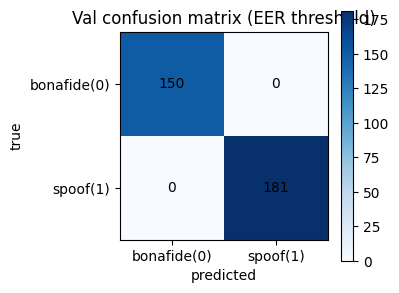

In [14]:
cm = confusion_matrix(val_labels, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['bonafide(0)', 'spoof(1)'])
ax.set_yticklabels(['bonafide(0)', 'spoof(1)'])
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Val confusion matrix (EER threshold)')
for i in (0, 1):
    for j in (0, 1):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=ax, shrink=0.7); fig.tight_layout(); plt.show()

In [15]:
# Per-provider recall on val. Bonafide rows: provider='original'.
# Spoof rows: provider in {'elevenlabs', 'google_tts'}.
from collections import defaultdict
buckets = defaultdict(lambda: {'y': [], 'p': []})
for i, m in enumerate(val_meta):
    key = m['provider'] or '<unknown>'
    buckets[key]['y'].append(int(val_labels[i]))
    buckets[key]['p'].append(int(y_pred[i]))

print(f"{'provider':14s} {'n':>5s} {'positives':>10s} {'recall':>8s}")
for prov in sorted(buckets):
    y = np.array(buckets[prov]['y']); p = np.array(buckets[prov]['p'])
    if y.size == 0:
        continue
    # 'recall' here = recall of the positive class present in this bucket.
    # Bonafide bucket: positive class = 0 (correctly-flagged bonafide).
    target = 1 if y.sum() > 0 else 0
    correct = int(((p == target) & (y == target)).sum())
    total = int((y == target).sum())
    rec = correct / total if total else float('nan')
    print(f"{prov:14s} {y.size:5d} {total:10d} {rec:8.4f}")

provider           n  positives   recall
elevenlabs       106        106   1.0000
google_tts        75         75   1.0000
original         150        150   1.0000


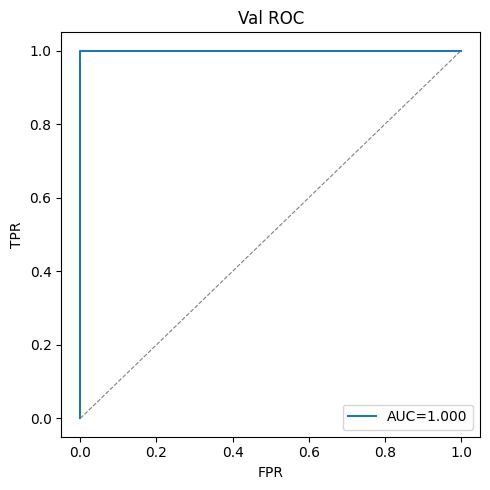

In [16]:
# ROC curve
fpr, tpr, _ = roc_curve(val_labels, val_probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f'AUC={val_auc:.3f}')
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Val ROC')
ax.legend(); fig.tight_layout(); plt.show()

## Update the checkpoint with EER and F1

Phase 6 reads these numbers when assembling the head-to-head comparison.

In [17]:
ckpt = torch.load(CKPT, map_location='cpu', weights_only=False)
ckpt['val_metrics'] = {
    'roc_auc': float(val_auc),
    'eer': float(val_eer),
    'eer_threshold': float(eer_thr),
    'f1': float(val_f1),
    'precision': float(val_prec),
    'recall': float(val_rec),
}
torch.save(ckpt, CKPT)
print('updated', CKPT, ckpt['val_metrics'])

updated models/checkpoints/best_mel_cnn.pt {'roc_auc': 1.0, 'eer': 0.0, 'eer_threshold': 0.7786626815795898, 'f1': 1.0, 'precision': 1.0, 'recall': 1.0}
